#### Create client connection

In [1]:
%load_ext autoreload
%autoreload 2

from geosave_engine.geodata.stac import StacClient, StacQuery

client = StacClient.planetary_computer()
client.collections()

{'3dep-lidar-classification',
 '3dep-lidar-copc',
 '3dep-lidar-dsm',
 '3dep-lidar-dtm',
 '3dep-lidar-dtm-native',
 '3dep-lidar-hag',
 '3dep-lidar-intensity',
 '3dep-lidar-pointsourceid',
 '3dep-lidar-returns',
 '3dep-seamless',
 'alos-dem',
 'alos-fnf-mosaic',
 'alos-palsar-mosaic',
 'aster-l1t',
 'chesapeake-lc-13',
 'chesapeake-lc-7',
 'chesapeake-lu',
 'chloris-biomass',
 'cil-gdpcir-cc-by',
 'cil-gdpcir-cc-by-sa',
 'cil-gdpcir-cc0',
 'conus404',
 'cop-dem-glo-30',
 'cop-dem-glo-90',
 'daymet-annual-hi',
 'daymet-annual-na',
 'daymet-annual-pr',
 'daymet-daily-hi',
 'daymet-daily-na',
 'daymet-daily-pr',
 'daymet-monthly-hi',
 'daymet-monthly-na',
 'daymet-monthly-pr',
 'deltares-floods',
 'deltares-water-availability',
 'drcog-lulc',
 'eclipse',
 'ecmwf-forecast',
 'era5-pds',
 'esa-cci-lc',
 'esa-cci-lc-netcdf',
 'esa-worldcover',
 'fia',
 'fws-nwi',
 'gap',
 'gbif',
 'gnatsgo-rasters',
 'gnatsgo-tables',
 'goes-cmi',
 'goes-glm',
 'gpm-imerg-hhr',
 'gridmet',
 'hgb',
 'hls2-l30',

#### Create query to search for stac items
Useful to know the properties of items for creating filters like cloud covers

In [2]:
query = StacQuery(
    collections=["sentinel-2-l2a"],
    bbox=(-5.0, 40.0, 5.0, 50.0),
    datetime="2023-01-01/2023-12-31",
    max_items=2,
)
items = client.search(query)
items[0].to_dict()

{'type': 'Feature',
 'stac_version': '1.1.0',
 'stac_extensions': ['https://stac-extensions.github.io/eo/v1.1.0/schema.json',
  'https://stac-extensions.github.io/sat/v1.0.0/schema.json',
  'https://stac-extensions.github.io/projection/v2.0.0/schema.json'],
 'id': 'S2A_MSIL2A_20231231T105441_R051_T31UFR_20231231T162152',
 'geometry': {'type': 'Polygon',
  'coordinates': [[[5.9064198, 50.5156646],
    [5.8637226, 50.4302952],
    [5.792411, 50.2859765],
    [5.7214025, 50.1416118],
    [5.6503657, 49.9972839],
    [5.5803346, 49.8528072],
    [5.5109418, 49.708286],
    [5.441884, 49.5637658],
    [5.4291558, 49.5371225],
    [4.3826844, 49.5564945],
    [4.4113495, 50.5437392],
    [5.9064198, 50.5156646]]]},
 'bbox': [4.38268436, 49.53712254, 5.90641984, 50.54373917],
 'properties': {'datetime': '2023-12-31T10:54:41.024000Z',
  'platform': 'Sentinel-2A',
  'instruments': ['msi'],
  's2:mgrs_tile': '31UFR',
  'constellation': 'Sentinel 2',
  's2:granule_id': 'S2A_OPER_MSI_L2A_TL_MSFT_2

#### Create connection to stac api collections
Establish the collection that we want to ingest, you can set the rule of ingestion here, like the bands, how the output dimension would be

In [3]:
source = client.source('sentinel-2-l2a')
source.sample_item()

<Item id=S2C_MSIL2A_20260906T154811_R054_T21WXV_20260906T202218>

In [4]:
source = source.set_config(
    bands=["B04", "B03", "B02"], # rgb
    item_properties=("s2:mean_solar_azimuth",),
    asset_fields=("center_wavelength",),
)
source = source.set_query(
    filter = "eo:cloud_cover < 10",
)

#### Loading Lazy Xarray
Use GeoAnchor as the guide to ingest data, we can build anchor from bbox, coordinate, , polygon, or geojson

In [5]:
import geosave_engine.geodata # noqa: F401
from geosave_engine.geodata import GeoAnchor

lat, lon  = -6.5914, 107.8416  # Center coordinate (latitude, longitude) for Jakarta, Indonesia
size_m = 500 # Produce 5km tile
resolution_m = 10 # Each pixel represents 10 m
time = "2026-07-01/2026-07-10" # Will be interpreted as 2026-07-01T00:00:00Z to 2026-07-31T23:59:59Z

anchor = GeoAnchor.from_coordinates(
    lat, lon, 
    shape=500,
    resolution=resolution_m, 
    timespan=time
)
raster = source.load(anchor)
print(f"Raster size: {raster.nbytes / (1024 * 1024)}")  # Size in MB)
raster

Raster size: 8.59072494506836


<xarray.Dataset> Size: 9MB
Dimensions:      (y: 500, x: 500, time: 3)
Coordinates:
  * y            (y) float64 4kB 9.273e+06 9.273e+06 ... 9.268e+06 9.268e+06
  * x            (x) float64 4kB 8.118e+05 8.118e+05 ... 8.167e+05 8.167e+05
  * time         (time) datetime64[ns] 24B 2026-07-02T02:55:19.024000 ... 202...
    spatial_ref  int32 4B 32748
Data variables:
    B04          (time, y, x) float32 3MB dask.array<chunksize=(1, 500, 500), meta=np.ndarray>
    B03          (time, y, x) float32 3MB dask.array<chunksize=(1, 500, 500), meta=np.ndarray>
    B02          (time, y, x) float32 3MB dask.array<chunksize=(1, 500, 500), meta=np.ndarray>
Attributes:
    id:            sentinel-2-l2a
    title:         Sentinel-2 Level-2A
    summary:       The [Sentinel-2](https://sentinel.esa.int/web/sentinel/mis...
    keywords:      Sentinel, Copernicus, ESA, Satellite, Global, Imagery, Ref...
    institution:   ESA
    license:       proprietary
    stac_items:    [{'id': 'S2A_MSIL2A_20260709T030151_R032_T48MZT_20260709T1...
    stac_groupby:  solar_day

In [11]:
from dask.diagnostics.progress import ProgressBar

with ProgressBar():
    raster = raster.compute()
    raster = raster.gs.rebase('render', {'rgb_variables': ['B04', 'B03', 'B02']})

[########################################] | 100% Completed | 27.52 ss


:NdLayout   [time]
   :RGB   [x,y]   (R,G,B)
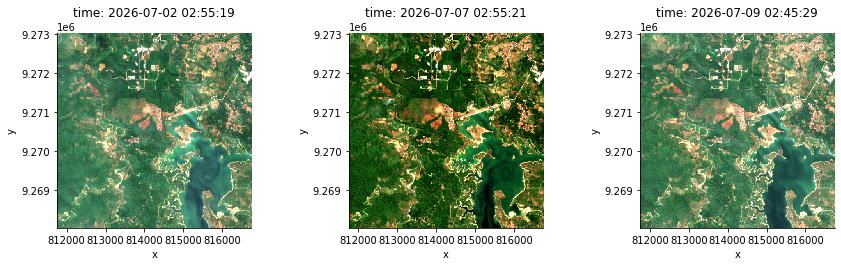

In [13]:
raster.gs.plot()

:Layout
   .RGB.I   :RGB   [x,y]   (R,G,B)
   .RGB.II  :RGB   [x,y]   (R,G,B)
   .RGB.III :RGB   [x,y]   (R,G,B)
   .RGB.IV  :RGB   [x,y]   (R,G,B)
   .RGB.V   :RGB   [x,y]   (R,G,B)
   .RGB.VI  :RGB   [x,y]   (R,G,B)
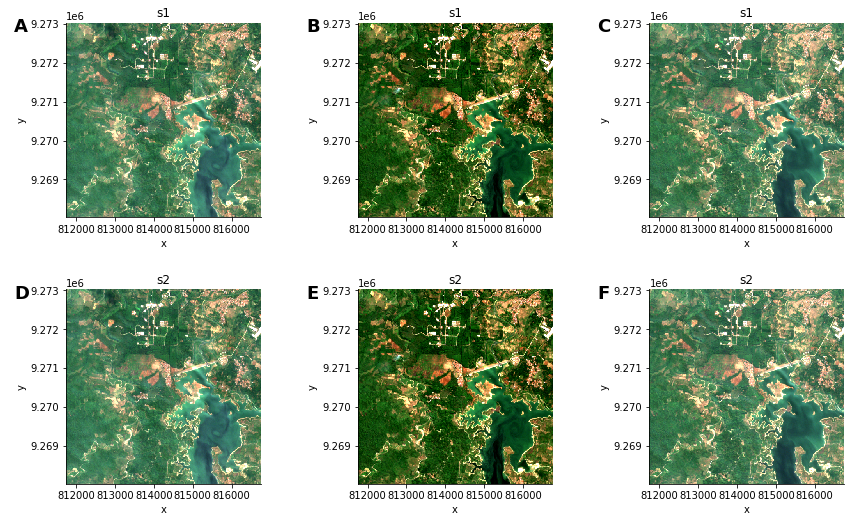

In [16]:
import geosave_engine.geodata as gd

gd.stack({'s1': raster, 's2': raster}).gs.plot(cols=3)

#### Unregistered STAC API

StacClient works universally for any STAC API, StacClient will manage error handling for you

In [10]:
from pystac_client import Client

custom_client = Client.open("https://stac.dataspace.copernicus.eu/v1/")
stac_client = StacClient(custom_client)